# Data Understanding

This notebook inspects each downloaded dataset, reports row counts and splits, checks whether Moroccan Darija is present, measures Darija vs non-Darija ratios, detects Latin characters, and builds one merged table with `text`, `src`, and `dialect`.


In [6]:
from pathlib import Path
import re

import pandas as pd
from IPython.display import display
from datasets import Dataset, DatasetDict, load_from_disk

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
raw_dir = repo_root / "data" / "raw"
interim_dir = repo_root / "data" / "interim"
interim_dir.mkdir(parents=True, exist_ok=True)

source_paths = {
    "dataset0": raw_dir / "dataset0",
    "dataset1": raw_dir / "dataset1",
    "dataset2": raw_dir / "dataset2",
    "dataset3": raw_dir / "dataset3",
    "dataset4": raw_dir / "dataset4",
}

source_labels = {
    "dataset0": "atlasia/Darija_LID_Anootation_10k",
    "dataset1": "atlasia/DODa-audio-dataset",
    "dataset2": "atlasia/Darija-LID",
    "dataset3": "UBC-NLP/alexandria",
    "dataset4": "atlasia/levantine_dialects",
}

latin_re = re.compile(r"[A-Za-z]")
arabic_re = re.compile(r"[\u0600-\u06FF]")


In [7]:
def contains_latin(text: str) -> bool:
    return isinstance(text, str) and bool(latin_re.search(text))


def contains_arabic(text: str) -> bool:
    return isinstance(text, str) and bool(arabic_re.search(text))


def normalize_label(value: str | None) -> str:
    value = "" if value is None else str(value).strip().lower()
    value = re.sub(r"[^a-z0-9]+", "_", value).strip("_")
    return value or "unknown"


def moroccan_script_label(text: str) -> str:
    if contains_latin(text) and not contains_arabic(text):
        return "latin_moroccan_dialect"
    return "arabic_moroccan_dialect"


def iter_splits(obj: Dataset | DatasetDict):
    if isinstance(obj, DatasetDict):
        return obj.items()
    if isinstance(obj, Dataset):
        return [("train", obj)]
    raise TypeError(f"Unsupported object type: {type(obj).__name__}")


def add_row(records: list[dict], text: str | None, src: str, dialect: str) -> None:
    if not isinstance(text, str):
        return
    text = text.strip()
    if not text:
        return
    records.append({"text": text, "src": src, "dialect": dialect})


In [8]:
partition_rows = []
merged_records = []

# dataset0
dataset0_label = source_labels["dataset0"]
dataset0 = load_from_disk(str(source_paths["dataset0"]))
for split_name, split_data in iter_splits(dataset0):
    darija_rows = sum(1 for value in split_data["is_darija"] if str(value).strip().lower() == "yes")
    total_rows = len(split_data)
    latin_rows = sum(1 for text in split_data["content"] if contains_latin(text))
    partition_rows.append(
        {
            "src": dataset0_label,
            "subset": dataset0_label,
            "split": split_name,
            "rows": total_rows,
            "darija_rows": darija_rows,
            "non_darija_rows": total_rows - darija_rows,
            "latin_rows": latin_rows,
        }
    )
    for row in split_data:
        dialect = "arabic_moroccan_dialect" if str(row["is_darija"]).strip().lower() == "yes" else "non_darija"
        add_row(merged_records, row["content"], dataset0_label, dialect)

# dataset1
dataset1_label = source_labels["dataset1"]
dataset1 = load_from_disk(str(source_paths["dataset1"]))
for split_name, split_data in iter_splits(dataset1):
    total_rows = len(split_data)
    latin_rows = sum(1 for text in split_data["darija_Latn"] if contains_latin(text))
    partition_rows.append(
        {
            "src": dataset1_label,
            "subset": dataset1_label,
            "split": split_name,
            "rows": total_rows,
            "darija_rows": total_rows,
            "non_darija_rows": 0,
            "latin_rows": latin_rows,
        }
    )
    for row in split_data.select_columns(["darija_Arab_new", "darija_Latn", "english"]):
        add_row(merged_records, row["darija_Arab_new"], dataset1_label, "arabic_moroccan_dialect")
        add_row(merged_records, row["darija_Latn"], dataset1_label, "latin_moroccan_dialect")
        add_row(merged_records, row["english"], dataset1_label, "english")

# dataset2
dataset2_label = source_labels["dataset2"]
dataset2 = load_from_disk(str(source_paths["dataset2"]))
for split_name, split_data in iter_splits(dataset2):
    darija_rows = sum(1 for value in split_data["label"] if str(value).strip().lower() == "ary")
    latin_rows = sum(1 for text in split_data["text"] if contains_latin(text))
    partition_rows.append(
        {
            "src": dataset2_label,
            "subset": dataset2_label,
            "split": split_name,
            "rows": len(split_data),
            "darija_rows": darija_rows,
            "non_darija_rows": len(split_data) - darija_rows,
            "latin_rows": latin_rows,
        }
    )
    for row in split_data.select_columns(["dialect", "text", "label"]):
        if str(row["label"]).strip().lower() == "ary":
            dialect = moroccan_script_label(row["text"])
        else:
            dialect = normalize_label(row["dialect"])
        add_row(merged_records, row["text"], dataset2_label, dialect)

# dataset3
dataset3_label = source_labels["dataset3"]
for cfg_dir in sorted(source_paths["dataset3"].iterdir()):
    if not cfg_dir.is_dir():
        continue

    cfg_name = cfg_dir.name
    cfg_data = load_from_disk(str(cfg_dir))
    for split_name, split_data in iter_splits(cfg_data):
        total_rows = len(split_data)
        darija_rows = sum(1 for country in split_data["country"] if str(country).strip().upper() == "MA")
        latin_rows = 0
        for conversation in split_data["dialectal_conversation"]:
            for turn in conversation:
                latin_rows += int(contains_latin(turn.get("text")))

        partition_rows.append(
            {
                "src": dataset3_label,
                "subset": cfg_name,
                "split": split_name,
                "rows": total_rows,
                "darija_rows": darija_rows,
                "non_darija_rows": total_rows - darija_rows,
                "latin_rows": latin_rows,
            }
        )

        selected = split_data.select_columns(["country", "dialect", "english_conversation", "dialectal_conversation"])
        for row in selected:
            is_ma = str(row["country"]).strip().upper() == "MA"
            dialect_label = normalize_label(row["dialect"])

            for turn in row["dialectal_conversation"]:
                text = turn.get("text")
                dialect = moroccan_script_label(text) if is_ma else dialect_label
                add_row(merged_records, text, dataset3_label, dialect)

            for turn in row["english_conversation"]:
                add_row(merged_records, turn.get("text"), dataset3_label, "english")

# dataset4
dataset4_label = source_labels["dataset4"]
dataset4 = load_from_disk(str(source_paths["dataset4"]))
for split_name, split_data in iter_splits(dataset4):
    latin_rows = sum(1 for text in split_data["text"] if contains_latin(text))
    partition_rows.append(
        {
            "src": dataset4_label,
            "subset": dataset4_label,
            "split": split_name,
            "rows": len(split_data),
            "darija_rows": 0,
            "non_darija_rows": len(split_data),
            "latin_rows": latin_rows,
        }
    )
    for row in split_data.select_columns(["dialect", "text"]):
        add_row(merged_records, row["text"], dataset4_label, normalize_label(row["dialect"]))


In [9]:
partition_summary_df = pd.DataFrame(partition_rows).sort_values(["src", "subset", "split"]).reset_index(drop=True)

source_summary_df = (
    partition_summary_df.groupby("src", as_index=False)
    .agg(
        total_rows=("rows", "sum"),
        subsets=("subset", lambda values: ", ".join(sorted(set(values)))),
        splits=("split", lambda values: ", ".join(sorted(set(values)))),
        darija_rows=("darija_rows", "sum"),
        non_darija_rows=("non_darija_rows", "sum"),
        latin_rows=("latin_rows", "sum"),
    )
)

source_summary_df["has_darija"] = source_summary_df["darija_rows"] > 0
source_summary_df["darija_ratio"] = (source_summary_df["darija_rows"] / source_summary_df["total_rows"]).round(4)
source_summary_df["non_darija_ratio"] = (source_summary_df["non_darija_rows"] / source_summary_df["total_rows"]).round(4)
source_summary_df["has_latin_chars"] = source_summary_df["latin_rows"] > 0
source_summary_df = source_summary_df[
    [
        "src",
        "subsets",
        "splits",
        "total_rows",
        "has_darija",
        "darija_rows",
        "non_darija_rows",
        "darija_ratio",
        "non_darija_ratio",
        "has_latin_chars",
        "latin_rows",
    ]
]

display(partition_summary_df)
display(source_summary_df)


,src,subset,split,rows,darija_rows,non_darija_rows,latin_rows
0,UBC-NLP/alexandria,EG,test,366,0,366,114
1,UBC-NLP/alexandria,EG,train,982,0,982,261
2,UBC-NLP/alexandria,JO,test,347,0,347,45
3,UBC-NLP/alexandria,JO,train,1730,0,1730,162
4,UBC-NLP/alexandria,LB,test,369,0,369,235
5,UBC-NLP/alexandria,LB,train,2915,0,2915,1564
6,UBC-NLP/alexandria,LY,test,374,0,374,15
7,UBC-NLP/alexandria,MA,test,353,353,0,329
8,UBC-NLP/alexandria,MA,train,815,815,0,848
9,UBC-NLP/alexandria,MR,test,357,0,357,78


,src,subsets,splits,total_rows,has_darija,darija_rows,non_darija_rows,darija_ratio,non_darija_ratio,has_latin_chars,latin_rows
0,UBC-NLP/alexandria,"EG, JO, LB, LY, MA, MR, OM, PS, SA, SD, SY, TN...","test, train",25852,True,1168,24684,0.0452,0.9548,True,6150
1,atlasia/DODa-audio-dataset,atlasia/DODa-audio-dataset,train,12743,True,12743,0,1.0000,0.0000,True,12741
2,atlasia/Darija-LID,atlasia/Darija-LID,"test, train",266129,True,188805,77324,0.7094,0.2906,True,2801
3,atlasia/Darija_LID_Anootation_10k,atlasia/Darija_LID_Anootation_10k,train,10564,True,9630,934,0.9116,0.0884,False,0
4,atlasia/levantine_dialects,atlasia/levantine_dialects,train,56652,False,0,56652,0.0000,1.0000,True,410


In [10]:
merged_df = pd.DataFrame(merged_records).drop_duplicates().reset_index(drop=True)

display(merged_df.head())
display(merged_df["src"].value_counts().rename_axis("src").reset_index(name="rows"))
display(merged_df["dialect"].value_counts().rename_axis("dialect").reset_index(name="rows").head(30))

merged_csv_path = interim_dir / "merged_text_src_dialect.csv"
summary_csv_path = interim_dir / "dataset_source_summary.csv"
partition_csv_path = interim_dir / "dataset_partition_summary.csv"

merged_df.to_csv(merged_csv_path, index=False)
source_summary_df.to_csv(summary_csv_path, index=False)
partition_summary_df.to_csv(partition_csv_path, index=False)

print(f"Merged rows: {len(merged_df):,}")
print(f"Saved merged table to: {merged_csv_path}")
print(f"Saved source summary to: {summary_csv_path}")
print(f"Saved partition summary to: {partition_csv_path}")


,text,src,dialect
0,الكل يعيب علا ركراكي هاد لعب هو لدي بيه الألقا...,atlasia/Darija_LID_Anootation_10k,arabic_moroccan_dialect
1,ملف فمجلس الامن بغتينا نديرو وقفه احتجاجيه حدا...,atlasia/Darija_LID_Anootation_10k,arabic_moroccan_dialect
2,ممكن تسكت راك مكتفيد الامه فحتا شي حاجه,atlasia/Darija_LID_Anootation_10k,arabic_moroccan_dialect
3,وانت الرومضاني شحال كيعطيوك ناس ديالك,atlasia/Darija_LID_Anootation_10k,arabic_moroccan_dialect
4,شتي أبو صليعه شنو درتي,atlasia/Darija_LID_Anootation_10k,arabic_moroccan_dialect


,src,rows
0,atlasia/Darija-LID,264108
1,UBC-NLP/alexandria,161380
2,atlasia/levantine_dialects,56324
3,atlasia/DODa-audio-dataset,35720
4,atlasia/Darija_LID_Anootation_10k,10552


,dialect,rows
0,arabic_moroccan_dialect,213829
1,english,92041
2,levant,55470
3,palestine,24830
4,msa,18979
5,syria,15272
6,jordan,12890
7,latin_moroccan_dialect,12464
8,lebanese_standard_dialect,10004
9,saudi_arabic_southern_dialect,6794


Merged rows: 528,084
Saved merged table to: /home/mohammed/Documents/AtlasIA/Darija_LID_Anootation_10k/darija-lid-benchmark/data/interim/merged_text_src_dialect.csv
Saved source summary to: /home/mohammed/Documents/AtlasIA/Darija_LID_Anootation_10k/darija-lid-benchmark/data/interim/dataset_source_summary.csv
Saved partition summary to: /home/mohammed/Documents/AtlasIA/Darija_LID_Anootation_10k/darija-lid-benchmark/data/interim/dataset_partition_summary.csv


## Final Dataset Overview

This section loads the final processed dataset and gives a compact visual summary of the information that matters most for the benchmark.


,metric,value
0,rows,471541.0
1,unique dialects,76.0
2,unique src values,5.0
3,rows with Latin script,113414.0
4,arabic_moroccan rows,213788.0
5,arabizi_moroccan rows,12482.0
6,other rows,245271.0
7,median tokens per row,7.0


,label,rows
0,other,245271
1,arabic_moroccan,213788
2,arabizi_moroccan,12482


,dialect,rows
0,arabic_moroccan,213788
1,english,92005
2,levant,27708
3,msa,18953
4,arabizi_moroccan,12482
5,palestine,12390
6,lebanese_standard_dialect,9992
7,syria,7635
8,saudi_arabic_southern_dialect,6781
9,mauritanian_hassaniya_dialect,6624


,src,rows
0,atlasia/Darija-LID,264090
1,UBC-NLP/alexandria,161329
2,atlasia/levantine_dialects,56318
3,atlasia/DODa-audio-dataset,35706
4,atlasia/Darija_LID_Anootation_10k,10547


/tmp/ipykernel_801766/3683592257.py:103: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = axes[2, 0].boxplot(token_samples, labels=label_order, patch_artist=True)


ValueError: cannot reindex on an axis with duplicate labels

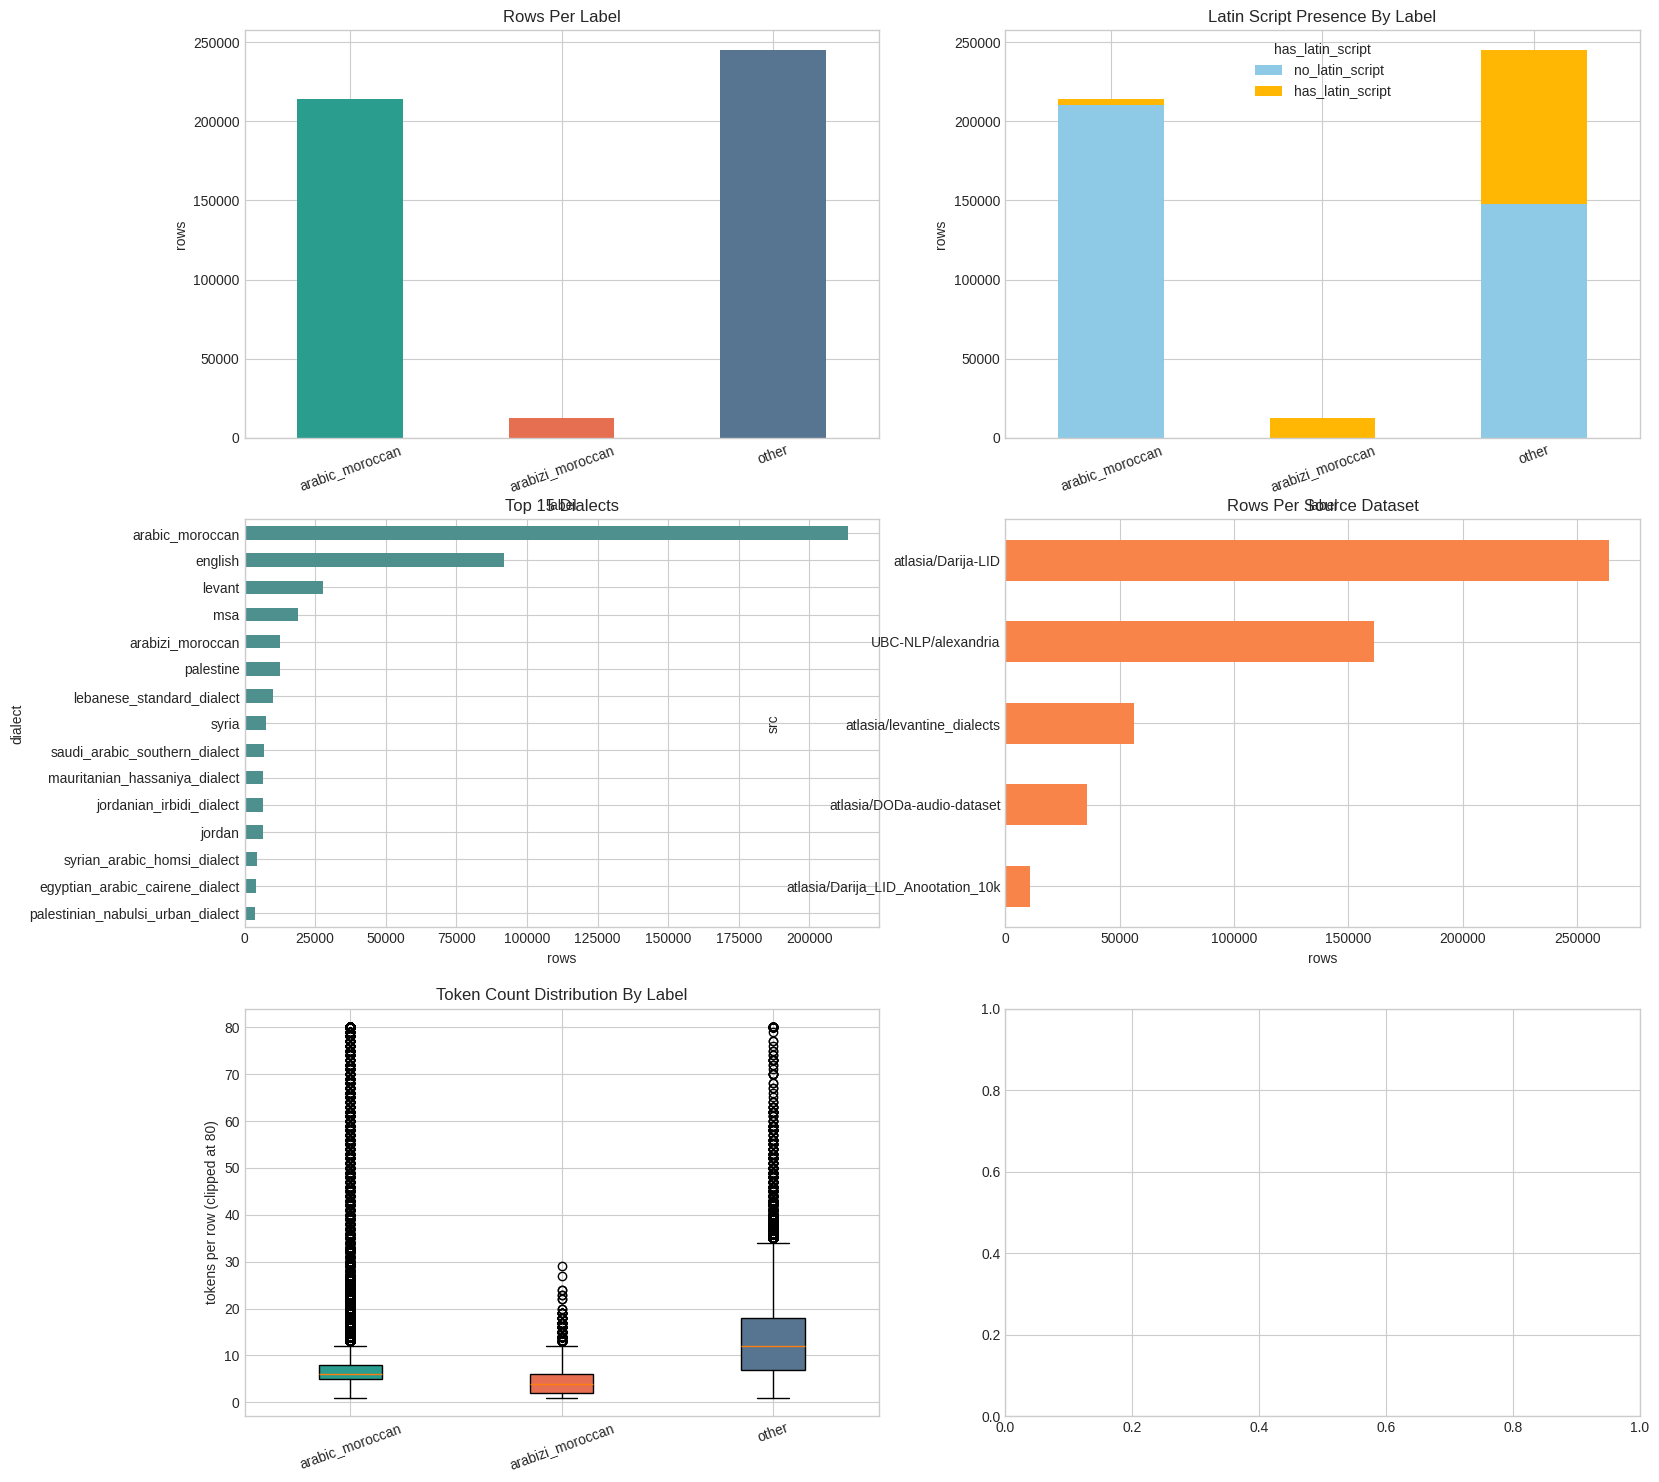

In [12]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Install matplotlib to render the final dataset graphs.") from exc

processed_dir = repo_root / "data" / "processed"
plots_dir = processed_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
final_dataset_path = processed_dir / "final_dataset.csv"

final_df = pd.read_csv(final_dataset_path)
final_df["label"] = final_df["label"].astype(int)
final_df["has_latin_script"] = final_df["has_latin_script"].astype(str).str.lower().eq("true")
final_df["text"] = final_df["text"].fillna("").astype(str)
final_df["has_arabic_script"] = final_df["text"].map(contains_arabic)

label_names = {
    0: "arabic_moroccan",
    1: "arabizi_moroccan",
    2: "other",
}
label_order = ["arabic_moroccan", "arabizi_moroccan", "other"]
label_colors = {
    "arabic_moroccan": "#2a9d8f",
    "arabizi_moroccan": "#e76f51",
    "other": "#577590",
}

final_df["label_name"] = final_df["label"].map(label_names)
final_df["n_chars"] = final_df["text"].str.len()
final_df["n_tokens"] = final_df["text"].str.split().str.len()

source_rows = (
    final_df.assign(src_name=final_df["src"].str.split("|", regex=False))
    .explode("src_name")
    .reset_index(drop=True)
)

overview_df = pd.DataFrame(
    {
        "metric": [
            "rows",
            "unique dialects",
            "unique src values",
            "rows with Latin script",
            "rows with Arabic script",
            "arabic_moroccan rows",
            "arabizi_moroccan rows",
            "other rows",
            "median tokens per row",
        ],
        "value": [
            len(final_df),
            final_df["dialect"].nunique(),
            source_rows["src_name"].nunique(),
            int(final_df["has_latin_script"].sum()),
            int(final_df["has_arabic_script"].sum()),
            int((final_df["label"] == 0).sum()),
            int((final_df["label"] == 1).sum()),
            int((final_df["label"] == 2).sum()),
            float(final_df["n_tokens"].median()),
        ],
    }
)

display(overview_df)
display(final_df["label_name"].value_counts().rename_axis("label").reset_index(name="rows"))
display(final_df["dialect"].value_counts().rename_axis("dialect").reset_index(name="rows").head(15))
display(source_rows["src_name"].value_counts().rename_axis("src").reset_index(name="rows"))

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(4, 2, figsize=(18, 22))

label_counts = final_df["label_name"].value_counts().reindex(label_order)
label_counts.plot(
    kind="bar",
    ax=axes[0, 0],
    color=[label_colors[label] for label in label_order],
    title="Rows Per Label",
)
axes[0, 0].set_xlabel("label")
axes[0, 0].set_ylabel("rows")
axes[0, 0].tick_params(axis="x", rotation=20)

latin_by_label = pd.crosstab(final_df["label_name"], final_df["has_latin_script"])
latin_by_label = latin_by_label.reindex(label_order).rename(columns={False: "no_latin_script", True: "has_latin_script"})
latin_by_label.plot(
    kind="bar",
    stacked=True,
    ax=axes[0, 1],
    color=["#8ecae6", "#ffb703"],
    title="Latin Script Presence By Label",
)
axes[0, 1].set_xlabel("label")
axes[0, 1].set_ylabel("rows")
axes[0, 1].tick_params(axis="x", rotation=20)

top_dialects = final_df["dialect"].value_counts().head(15).sort_values()
top_dialects.plot(kind="barh", ax=axes[1, 0], color="#4d908e", title="Top 15 Dialects")
axes[1, 0].set_xlabel("rows")
axes[1, 0].set_ylabel("dialect")

top_sources = source_rows["src_name"].value_counts().head(10).sort_values()
top_sources.plot(kind="barh", ax=axes[1, 1], color="#f9844a", title="Rows Per Source Dataset")
axes[1, 1].set_xlabel("rows")
axes[1, 1].set_ylabel("src")

token_samples = [
    final_df.loc[final_df["label_name"] == label_name, "n_tokens"].clip(upper=80)
    for label_name in label_order
]
boxplot = axes[2, 0].boxplot(token_samples, labels=label_order, patch_artist=True)
for patch, label_name in zip(boxplot["boxes"], label_order):
    patch.set_facecolor(label_colors[label_name])
axes[2, 0].set_title("Token Count Distribution By Label")
axes[2, 0].set_ylabel("tokens per row (clipped at 80)")
axes[2, 0].tick_params(axis="x", rotation=20)

source_label_counts = pd.crosstab(source_rows["src_name"], source_rows["label_name"])
source_label_counts = source_label_counts.reindex(index=top_sources.index, columns=label_order).fillna(0)
source_label_counts.plot(
    kind="barh",
    stacked=True,
    ax=axes[2, 1],
    color=[label_colors[label] for label in label_order],
    title="Label Mix By Source Dataset",
)
axes[2, 1].set_xlabel("rows")
axes[2, 1].set_ylabel("src")

other_df = final_df.loc[final_df["label_name"] == "other"].copy()
other_script_breakdown = pd.Series({
    "arabic_only": int((other_df["has_arabic_script"] & ~other_df["has_latin_script"]).sum()),
    "latin_only": int((~other_df["has_arabic_script"] & other_df["has_latin_script"]).sum()),
    "arabic_and_latin": int((other_df["has_arabic_script"] & other_df["has_latin_script"]).sum()),
    "neither": int((~other_df["has_arabic_script"] & ~other_df["has_latin_script"]).sum()),
})
other_script_breakdown.plot(
    kind="bar",
    ax=axes[3, 0],
    color=["#277da1", "#f94144", "#f9c74f", "#9c89b8"],
    title="Script Breakdown Inside Other Rows",
)
axes[3, 0].set_xlabel("script pattern")
axes[3, 0].set_ylabel("rows")
axes[3, 0].tick_params(axis="x", rotation=20)

other_by_source = pd.crosstab(source_rows["src_name"], source_rows["label_name"]).get("other")
if other_by_source is not None:
    other_by_source = other_by_source.sort_values().tail(10)
    other_by_source.plot(kind="barh", ax=axes[3, 1], color="#6d597a", title="Other Rows Per Source Dataset")
    axes[3, 1].set_xlabel("rows")
    axes[3, 1].set_ylabel("src")
else:
    axes[3, 1].axis("off")

plt.tight_layout()
plot_output_path = plots_dir / "final_dataset_dashboard.png"
fig.savefig(plot_output_path, dpi=200, bbox_inches="tight")
print(f"Saved final dataset dashboard to: {plot_output_path}")
plt.show()
